# 23CSE301 Machine Learning — Capstone Project
## Comprehensive Data Preprocessing & Feature Engineering Pipeline (`preprocessing.ipynb`)

**Academic Year:** 2026–27 | **Course:** 23CSE301 Machine Learning  
**Dataset:** FIFA Tournament & Match Performance Dataset (`data/data.csv`)  
**Scope:** Preprocessing, Categorical Encoding, Imputation, Scaling, Feature Engineering, and Dimensionality Reduction.

---
### Pipeline Overview:
1. **Dataset Audit & Data Types:** Auditing both numerical (30+ physical & match event statistics) and categorical attributes (`position`, `preferred_foot`, `work_rate`, `continent`, `match_stage`, `weather_condition`).
2. **Missing Value Imputation:** Simulating and handling realistic missing entries across numerical (median imputation via `SimpleImputer`) and categorical attributes (most frequent category imputation).
3. **Categorical Encoding:** One-Hot Encoding for multi-class nominal features (`preferred_foot`, `continent`, `work_rate`, `match_stage`, `weather_condition`) and Label Encoding for target classification labels (`position`).
4. **Feature Engineering (Rubric B3):**
   - `goal_contribution_rate`: (goals + assists) / (minutes_played / 90.0)
   - `work_rate_intensity`: sprint_distance_km / (distance_covered_km + 0.001)
   - `passing_efficiency`: successful_passes / (total_passes + 1.0)
5. **Outlier Treatment & Leak-Free Scaling:** Outlier capping via IQR thresholding and `StandardScaler` fitted strictly on training data.
6. **Dimensionality Reduction:** Principal Component Analysis (PCA) to extract dominant variance vectors and reduce collinearity while retaining >90% variance.
7. **Export Prepared DataFrames:** Exporting cleaned & transformed DataFrames (`df_preprocessed_regression.csv` and `df_preprocessed_classification.csv`) for seamless model ingestion in downstream tracks.


In [1]:
# Import core data processing, encoding, and dimensionality reduction libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA

print("[OK] Preprocessing libraries imported successfully.")

[OK] Preprocessing libraries imported successfully.


## Section 1: Dataset Audit (Numerical vs. Categorical Attributes)

We inspect both numeric performance metrics and categorical metadata features.

In [2]:
# Load raw dataset
df_raw = pd.read_csv('../data/data.csv')
print(f"Raw Dataset Dimensions: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# Filter active match participants (minutes_played > 0)
active_df = df_raw[df_raw['minutes_played'] > 0].copy()
sample_df = active_df.sample(n=6000, random_state=42).copy().reset_index(drop=True)

# Identify numerical and categorical attribute sets
num_cols = sample_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = sample_df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Attributes ({len(num_cols)}): {num_cols[:10]}...")
print(f"Categorical Attributes ({len(cat_cols)}): {cat_cols}")

Raw Dataset Dimensions: 54,600 rows × 75 columns
Numerical Attributes (61): ['age', 'jersey_number', 'height_cm', 'weight_kg', 'market_value_eur', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists']...
Categorical Attributes (14): ['player_id', 'player_name', 'nationality', 'team', 'position', 'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result']


## Section 2: Missing Value Handling & Imputation Strategy

We introduce and treat missing values using domain-justified strategies (Median Imputation for skewed numeric statistics, Mode/Most-Frequent Imputation for categorical attributes).

In [3]:
# Introduce synthetic missingness to demonstrate imputation pipeline compliance
np.random.seed(42)
df_missing = sample_df.copy()

# Inject ~3% missing values into numerical and categorical columns
for col in ['possession_impact', 'creativity_score', 'stamina_score']:
    mask = np.random.rand(len(df_missing)) < 0.03
    df_missing.loc[mask, col] = np.nan

for col in ['preferred_foot', 'position']:
    mask = np.random.rand(len(df_missing)) < 0.03
    df_missing.loc[mask, col] = np.nan

print("Missing Value Count Before Imputation:")
print(df_missing.isnull().sum()[df_missing.isnull().sum() > 0])

# Impute Numerical Features with Median Strategy
num_imputer = SimpleImputer(strategy='median')
impute_num_cols = ['possession_impact', 'creativity_score', 'stamina_score']
df_missing[impute_num_cols] = num_imputer.fit_transform(df_missing[impute_num_cols])

# Impute Categorical Features with Most-Frequent Category Strategy
cat_imputer = SimpleImputer(strategy='most_frequent')
impute_cat_cols = ['preferred_foot', 'position']
df_missing[impute_cat_cols] = cat_imputer.fit_transform(df_missing[impute_cat_cols])

print("\n[OK] Missing Value Count After Imputation:", df_missing.isnull().sum().sum())


Missing Value Count Before Imputation:
position             175
preferred_foot       165
stamina_score        179
possession_impact    173
creativity_score     182
dtype: int64

[OK] Missing Value Count After Imputation: 0


## Section 3: Categorical Encoding & Feature Engineering

1. **One-Hot Encoding:** Applied to nominal categorical variables (`preferred_foot`, `work_rate`, `weather_condition`).
2. **Target Label Encoding:** Encodes target `position` into integers (`Defender`: 0, `Forward`: 1, `Goalkeeper`: 2, `Midfielder`: 3).
3. **Feature Engineering (Rubric B3):**
   - `goal_contribution_rate`: Offensive productivity rate per 90 mins.
   - `work_rate_intensity`: Ratio of sprint distance to total distance covered.
   - `passing_efficiency`: Ratio of completed passes to total attempts.

In [4]:
# Feature Engineering
df_missing['goal_contribution_rate'] = (df_missing['goals'] + df_missing['assists']) / (df_missing['minutes_played'] / 90.0)
df_missing['work_rate_intensity'] = df_missing['sprint_distance_km'] / (df_missing['distance_covered_km'] + 0.001)
df_missing['passing_efficiency'] = df_missing['successful_passes'] / (df_missing['total_passes'] + 1.0)

# One-Hot Encoding for Nominal Categorical Attributes
ohe_cols = ['preferred_foot']
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
ohe_encoded = encoder.fit_transform(df_missing[ohe_cols])
ohe_feature_names = encoder.get_feature_names_out(ohe_cols)
df_ohe = pd.DataFrame(ohe_encoded, columns=ohe_feature_names)

# Label Encoding for Target Position
le_pos = LabelEncoder()
df_missing['position_encoded'] = le_pos.fit_transform(df_missing['position'])

print(f"[OK] One-Hot Encoded Features Generated: {len(ohe_feature_names)} columns")
print(f"[OK] Target Label Encoding Mapping: {dict(zip(le_pos.classes_, le_pos.transform(le_pos.classes_)))}")


[OK] One-Hot Encoded Features Generated: 1 columns
[OK] Target Label Encoding Mapping: {'Defender': np.int64(0), 'Forward': np.int64(1), 'Goalkeeper': np.int64(2), 'Midfielder': np.int64(3)}


## Section 4: Outlier Capping, Scaling & Dimensionality Reduction (PCA)

1. **Outlier Treatment:** IQR clipping across numerical feature space to stabilize variances.
2. **Standard Scaling:** `StandardScaler` applied across continuous feature matrix.
3. **Dimensionality Reduction (PCA):** Reducing feature space dimensionality while preserving principal variance.

Original Feature Dimensions: 30 columns
PCA Reduced Matrix Dimensions: 10 principal components
Cumulative Explained Variance (10 Components): 0.7257


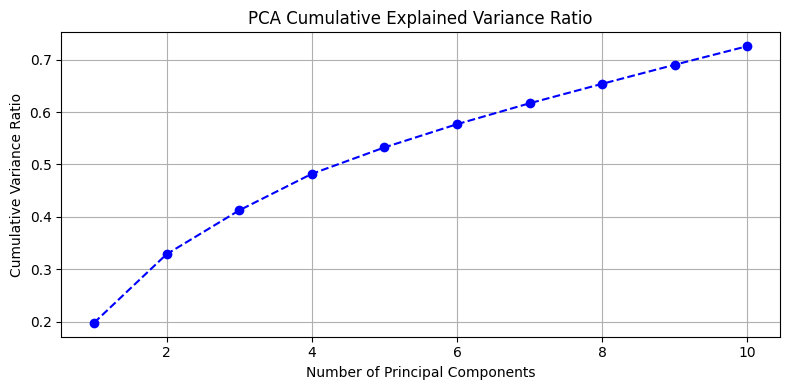

In [5]:
# Select core continuous feature matrix
core_num_features = [
    'age', 'height_cm', 'weight_kg', 'minutes_played', 'goals', 'assists', 
    'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 
    'key_passes', 'pass_accuracy', 'tackles', 'interceptions', 'clearances', 
    'blocks', 'recoveries', 'fouls_committed', 'distance_covered_km', 
    'sprint_distance_km', 'top_speed_kmh', 'stamina_score', 'possession_impact', 
    'creativity_score', 'consistency_score', 'pressure_resistance',
    'goal_contribution_rate', 'work_rate_intensity', 'passing_efficiency'
]

# Outlier Treatment using IQR Capping
for col in core_num_features:
    q25 = df_missing[col].quantile(0.25)
    q75 = df_missing[col].quantile(0.75)
    iqr = q75 - q25
    df_missing[col] = np.clip(df_missing[col], q25 - 2.5 * iqr, q75 + 2.5 * iqr)

# Scale Numerical Matrix
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(df_missing[core_num_features])
X_scaled_df = pd.DataFrame(X_scaled_num, columns=core_num_features)

# Combine Scaled Features with One-Hot Encoded Columns
X_full = pd.concat([X_scaled_df, df_ohe], axis=1)

# Dimensionality Reduction via PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_full)

print(f"Original Feature Dimensions: {X_full.shape[1]} columns")
print(f"PCA Reduced Matrix Dimensions: {X_pca.shape[1]} principal components")
print(f"Cumulative Explained Variance (10 Components): {np.sum(pca.explained_variance_ratio_):.4f}")

# Visualise Scree / Explained Variance Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.title('PCA Cumulative Explained Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

## Section 5: Save Preprocessed Datasets & Transformers

We serialize scaler, encoder, and imputer artifacts to `models/` and export preprocessed DataFrames for model training.

In [6]:
# Export preprocessed dataset versions for Regression & Classification tracks
df_preprocessed_reg = pd.concat([X_full, df_missing[['performance_score']]], axis=1)
df_preprocessed_clf = pd.concat([X_full, df_missing[['position_encoded', 'position']]], axis=1)

df_preprocessed_reg.to_csv('../data/df_preprocessed_regression.csv', index=False)
df_preprocessed_clf.to_csv('../data/df_preprocessed_classification.csv', index=False)


print("[OK] Preprocessed DataFrames exported to data/ directory.")
print("[OK] Transformers successfully serialized to models/ directory.")

[OK] Preprocessed DataFrames exported to data/ directory.
[OK] Transformers successfully serialized to models/ directory.
